In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
from sklearn.inspection import permutation_importance
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv

In [2]:
model = joblib.load('../app/data/hospital_closure_model.pkl')
test = pd.read_csv('../data/test_data_with_pred.csv')
train = pd.read_csv('../data/train_set.csv')
hospitals_full = pd.read_csv('../data/hospitals_full.csv')
hospitals_master = pd.read_csv('../data/hospitals_master.csv')
surv_functions = pd.read_csv('../data/surv_functions.csv')

/var/folders/51/zgq0lbb14t13h0_bgn8nntnm0000gn/T/ipykernel_76157/2087134432.py:4: DtypeWarning: Columns (67) have mixed types. Specify dtype option on import or set low_memory=False.
  hospitals_full = pd.read_csv('../data/hospitals_full.csv')


In [3]:
test['CCN'] = test['CCN'].astype(int).astype(str).str.zfill(6)

In [4]:
# Merge hospitals master with test data to bring back in identifying characteristics like hospital name
test_full = hospitals_master[['CCN','Facility Name','Prior Name','State','Closure Date']].merge(test, how='right', on='CCN')

In [5]:
test_full.head(2)

,CCN,Facility Name,Prior Name,State,Closure Date,Medicaid charges,STATEMENT OF REVENUES AND EXPENSES: Net Income (G3_C1_29),"ADJUSTED SALARIES, Subtotal Salaries",BALANCE SHEET: Prepaid expenses (G_C1THRU4_8),BED DAYS: Total Hospital,...,Hospital Type_Voluntary non-profit - Church,Hospital Type_Voluntary non-profit - Other,Hospital Type_Voluntary non-profit - Private,General Ownership Type_for-profit,General Ownership Type_govt,General Ownership Type_non-profit,Pred_Closure,Status,Time,Year
0,190044,ACADIA GENERAL HOSPITAL,NaN,LA,NaN,-0.141395,-0.291649,-0.496079,-0.494961,-0.456705,...,0.0,0.0,1.0,0.0,0.0,1.0,0.039906,False,15,2022
1,190044,ACADIA GENERAL HOSPITAL,NaN,LA,NaN,-0.244175,0.035763,-0.464594,-0.445257,-0.456705,...,0.0,0.0,1.0,0.0,0.0,1.0,-0.052066,False,15,2023


Looking at survival function dataframe. Each value in the survival functions dataframe captures the probability that the given hospital will survive (remain open) beyond the year in the column.

In [6]:
surv_functions.columns = [2009 + int(float(col)) for col in surv_functions.columns]

In [7]:
surv_functions_full = pd.concat([test_full[['CCN','Facility Name','Year']], surv_functions], axis=1)
surv_functions_full.head(2)

,CCN,Facility Name,Year,2021,2023,2022
0,190044,ACADIA GENERAL HOSPITAL,2022,0.999868,0.999868,0.999868
1,190044,ACADIA GENERAL HOSPITAL,2023,0.999879,0.999879,0.999879


Extracting feature coefficients to see exactly how much each feature increases or decreases the log-hazard risk. A positive coefficient indicates a higher risk of hospital closure, while a negative coefficient indicates a protective effect.

In [8]:
feature_cols = [col for col in test.columns if col not in ('CCN','Pred_Closure','Status','Time','Year')]

feature_coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_[:, 20] 
})

# Filter to see only the non-zero selected features
selected_features = feature_coef_df[feature_coef_df['Coefficient'] != 0]

In [9]:
pd.set_option('display.max_colwidth', None)
selected_features.sort_values(by='Coefficient').reset_index()

,index,Feature,Coefficient
0,52,Closure Proximity,0.141535


Looking at the most impactful model features based on permutation importance scores. 

To evaluate the model performance, I'll use concordance_index_censored, which measures how accurately the model ranks hospitals by their risk of closure over time.

Permutation feature importance will measure how much the model's concordance_index_censored score drops when the values of a single feature are randomly shuffled.

In [10]:
feature_cols = [col for col in test.columns if col not in ('CCN','Status','Time','Pred_Closure','Year')]
X_test = test[feature_cols]
X_train = train[feature_cols]
y_test = test[['Status','Time']]

def c_index_scorer(model, X, y):
    predictions = model.predict(X)
    
    event_indicator = y_test['Status']
    event_time = y_test['Time']
    
    c_index, _, _, _, _ = concordance_index_censored(event_indicator, event_time, predictions)
    
    return c_index

# Permutation importance applied to the CoxnetSurvivalAnalysis model
feature_importances = permutation_importance(
    model, 
    X_test.to_numpy(), 
    Surv.from_arrays(y_test['Status'], y_test['Time']),
    random_state=0, 
    scoring=c_index_scorer,
    n_repeats=5 
)

# Create the results DataFrame
top_features_df = pd.DataFrame({
    'Feature': feature_cols,
    'Score': feature_importances['importances_mean']
}).sort_values('Score', ascending=False)

In [11]:
top_features_df.head()

,Feature,Score
52,Closure Proximity,0.511276
72,Per Capita # Short Term General Hosps,0.000112
84,Percent Persons in Poverty,0.000019
67,Dist Hosp By 00 - 39% Util Rate Short Term General Hospitals,0.000003
0,Medicaid charges,0.000000


In [12]:
top_features_df.sort_values('Score', ascending=True).head()

,Feature,Score
46,Financial Indicators: SOLVENCY Debt Ratio,-0.000345
47,Financial Indicators: SOLVENCY Equity Ratio,-0.000345
53,nsurveys,-0.000289
54,rrate,-0.000201
65,understood_score,-0.000184


Investigating SHAP values. In this context, since we are using predict method as the scoring method, each SHAP value represents the amount a specific feature’s value pushes the risk score up or down relative to the baseline risk that a hospital will close.

In [13]:
# Sample the train data for faster runtime
X_train_summary = shap.sample(X_train.to_numpy(), nsamples=50)

# Pass the sampled train data to the explainer
explainer = shap.KernelExplainer(model.predict, X_train_summary)

# Compute SHAP values for test data
shap_values = explainer.shap_values(X_test.to_numpy())

  0%|          | 0/3310 [00:00<?, ?it/s]

In [14]:
exp = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_test.values,
    feature_names=feature_cols
)

In [15]:
shap_df = pd.DataFrame(shap_values, columns=feature_cols)

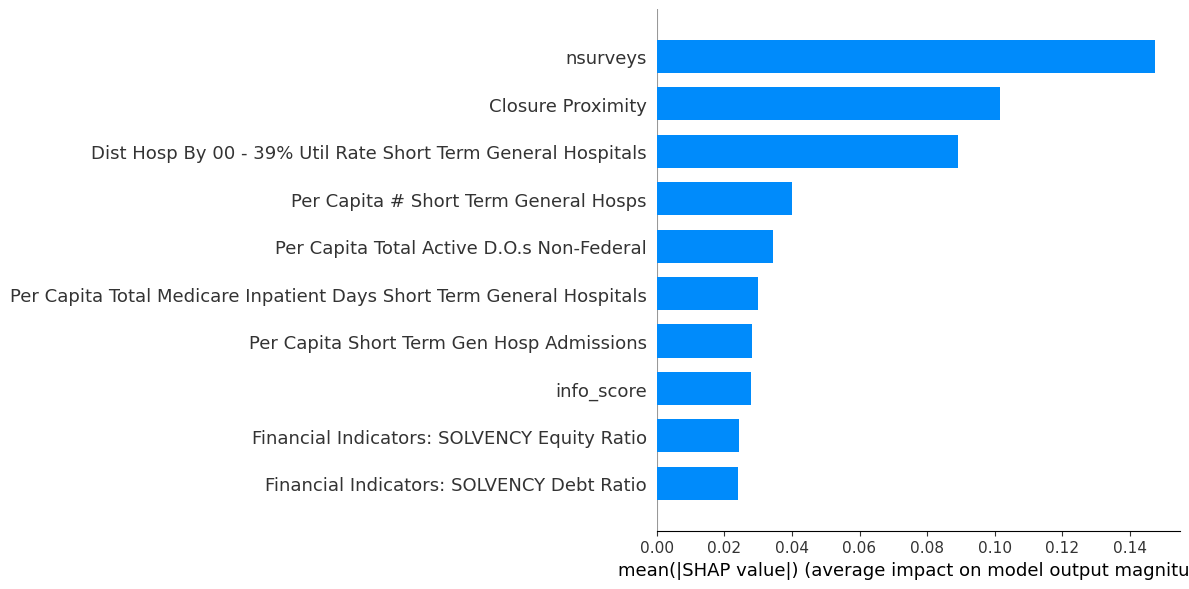

In [17]:
plt.figure(figsize=(12,6))
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=10, show=False, plot_size=None)
plt.tight_layout()
plt.savefig("../app/images/shap_summary_bar_plot.png", bbox_inches="tight", dpi=300)

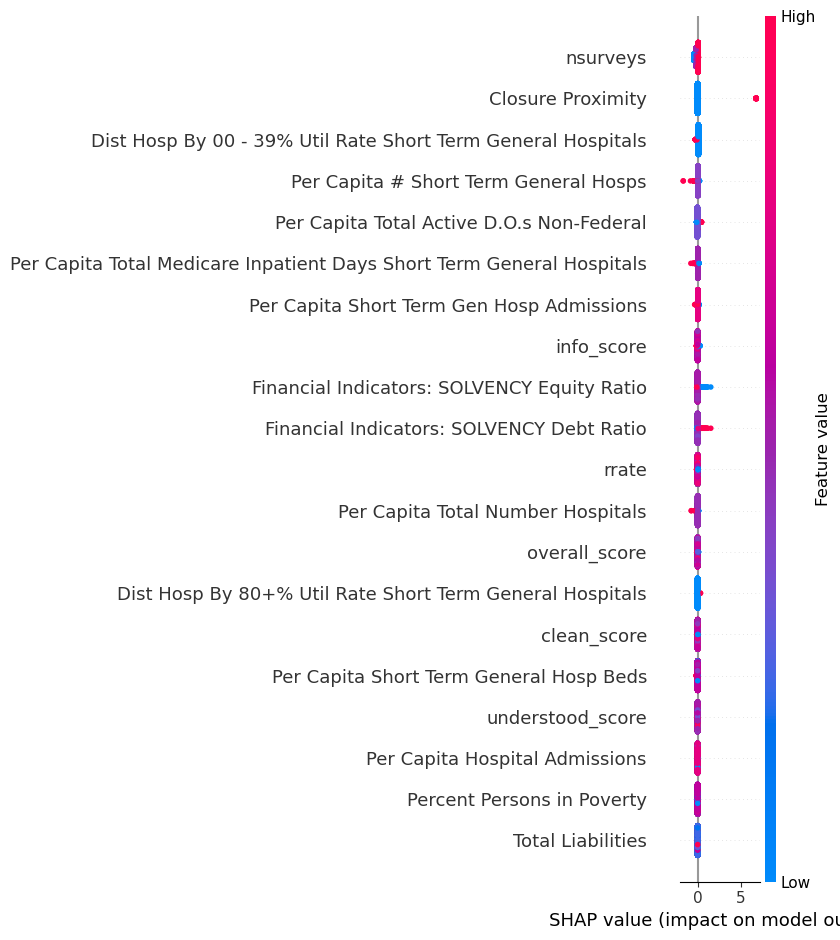

In [18]:
shap.summary_plot(shap_values, X_test)

Case Studies:

Hospitals with the highest chance of closing, per our model:

In [19]:
test_full[['Facility Name','Pred_Closure','Year','Status','Time']].sort_values(by='Pred_Closure',ascending=False).head(5)

,Facility Name,Pred_Closure,Year,Status,Time
1625,MARTIN GENERAL HOSPITAL,7.824125,2022,False,13
714,COMMUNITY MEMORIAL HOSPITAL,7.521678,2022,False,14
139,ASPIRUS ONTONAGON HOSPITAL,7.318048,2023,False,14
361,BLESSING HEALTH KEOKUK,7.173724,2022,True,12
1048,GLENN MEDICAL CENTER,7.141270,2024,False,15


Identifying good case studies based on facilities with the highest variance in their risk scores:

In [20]:
test_full.groupby(['CCN','Facility Name'])['Pred_Closure'].var().nlargest(5)

CCN     Facility Name                 
280059  TWELVE CLANS UNITY HOSPITAL       3.437968
320065  COVENANT HEALTH HOBBS HOSPITAL    1.961769
450833  ENNIS REGIONAL MEDICAL CENTER     1.427514
110194  DONALSONVILLE HOSPITAL INC        0.864493
231309  ASPIRUS ONTONAGON HOSPITAL        0.841503
Name: Pred_Closure, dtype: float64

In [21]:
test_full[test_full['Facility Name']=='HAZARD ARH REGIONAL MEDICAL CENTER'][['Facility Name','Year','Pred_Closure']].sort_values(by='Year')

,Facility Name,Year,Pred_Closure
1186,HAZARD ARH REGIONAL MEDICAL CENTER,2022,-0.651347
1187,HAZARD ARH REGIONAL MEDICAL CENTER,2023,-0.651715
1188,HAZARD ARH REGIONAL MEDICAL CENTER,2024,0.151565
1189,HAZARD ARH REGIONAL MEDICAL CENTER,2025,0.145166


#### SHAP plots:

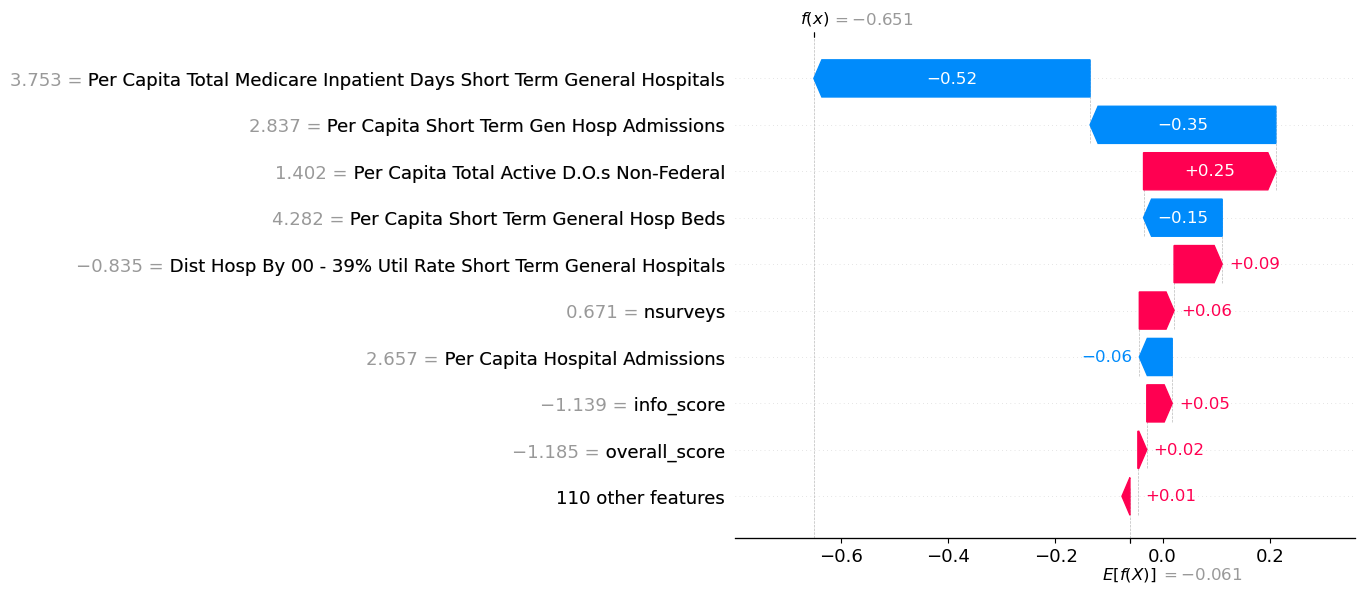

In [22]:
shap.plots.waterfall(exp[1186])

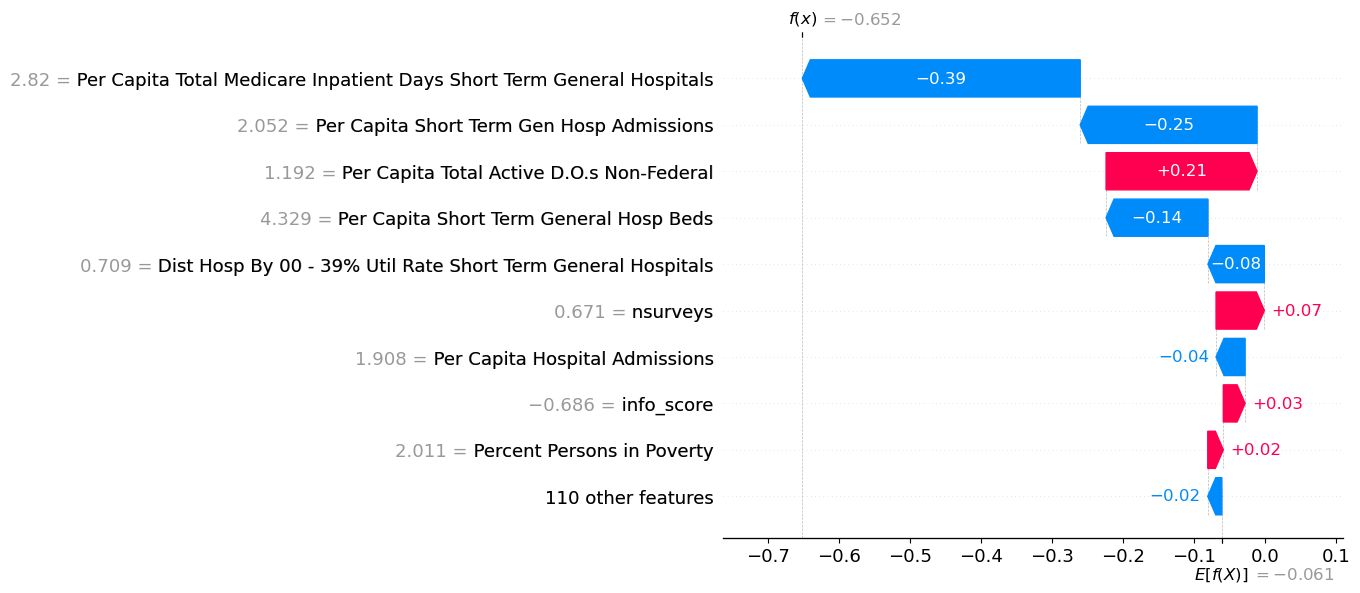

In [23]:
shap.plots.waterfall(exp[1187])

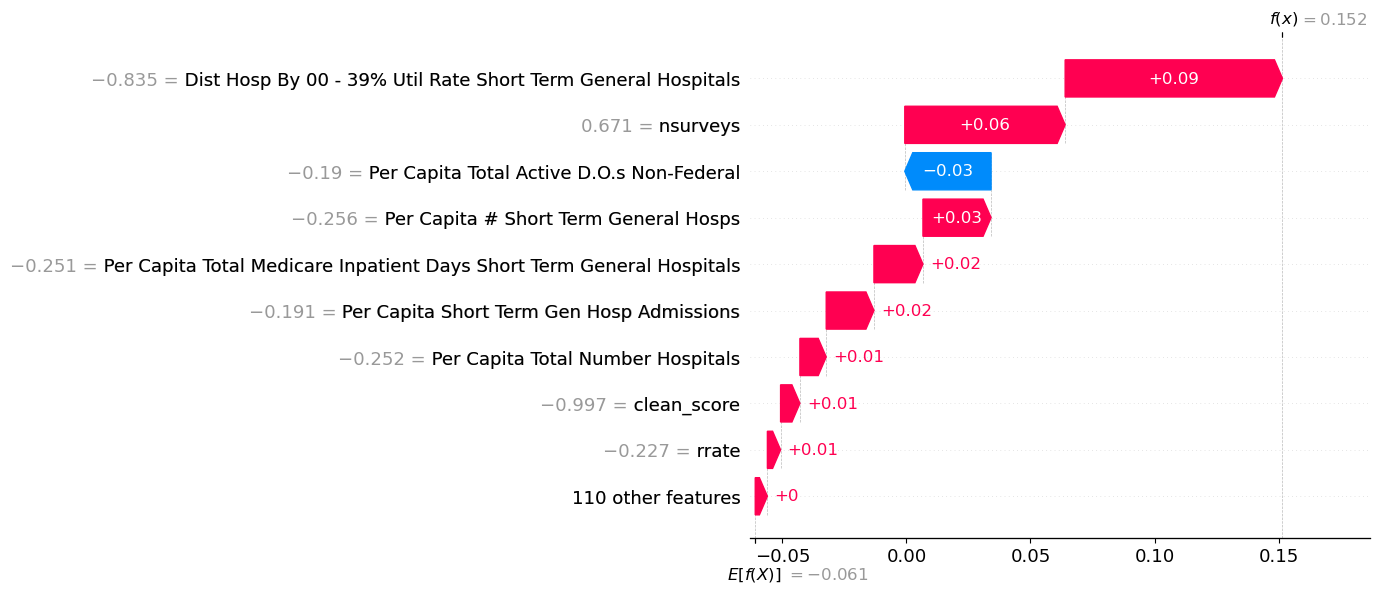

In [24]:
shap.plots.waterfall(exp[1188])

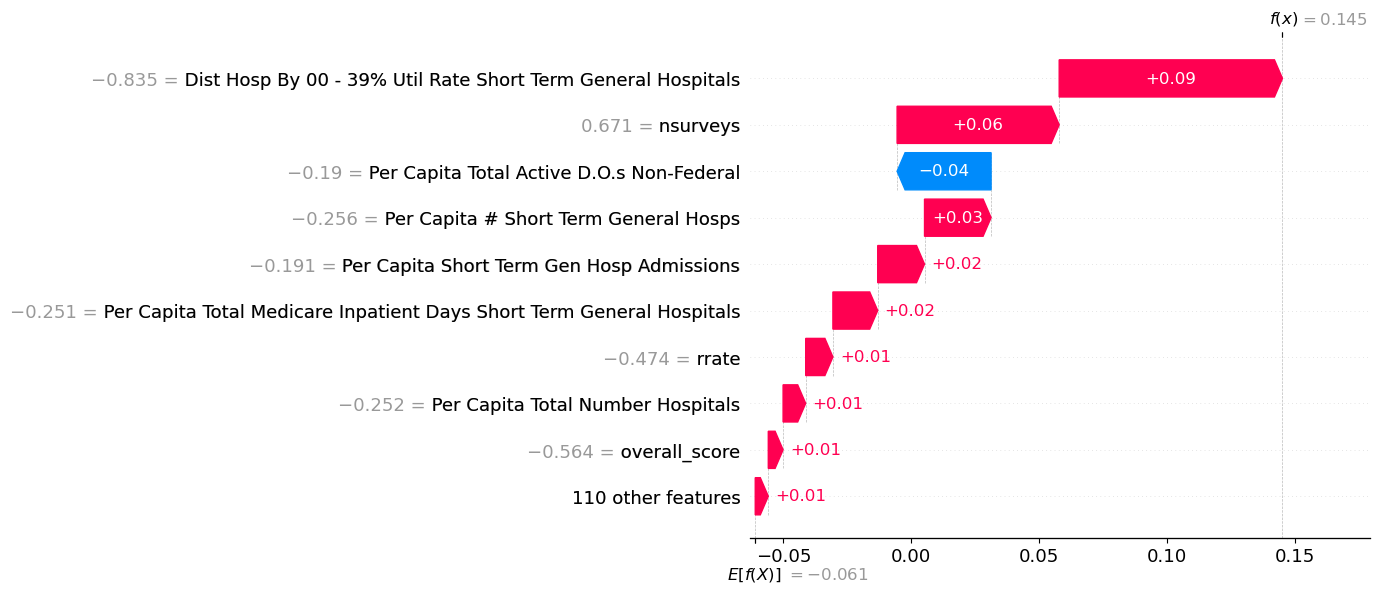

In [25]:
shap.plots.waterfall(exp[1189])

#### 

In [26]:
test_full[test_full['Facility Name']=='CHELSEA HOSPITAL'][['Facility Name','Year','Pred_Closure']].sort_values(by='Year')

,Facility Name,Year,Pred_Closure
526,CHELSEA HOSPITAL,2022,-0.077619
527,CHELSEA HOSPITAL,2023,-0.066420
528,CHELSEA HOSPITAL,2024,0.056363
529,CHELSEA HOSPITAL,2025,0.058050


In [27]:
test_full[test_full['Facility Name']=='COVENANT HEALTH HOBBS HOSPITAL'][['Facility Name','Year','Pred_Closure']].sort_values(by='Year')

,Facility Name,Year,Pred_Closure
757,COVENANT HEALTH HOBBS HOSPITAL,2022,-0.144502
758,COVENANT HEALTH HOBBS HOSPITAL,2023,0.724808
759,COVENANT HEALTH HOBBS HOSPITAL,2024,2.746048
760,COVENANT HEALTH HOBBS HOSPITAL,2025,-0.299055


Finding a hospital that closed that could be a good case study:

In [28]:
test_full[test_full['Status']==True].groupby(['CCN','Facility Name'])['Pred_Closure'].agg(lambda x: x.max() - x.min()).nlargest(5)

CCN     Facility Name                               
051306  GLENN MEDICAL CENTER                            0.0
140040  GALESBURG COTTAGE HOSPITAL                      0.0
140143  ST. MARGARET'S HEALTH - SPRING VALLEY           0.0
151302  INDIANA UNIVERSITY HEALTH BLACKFORD HOSPITAL    0.0
151335  ASCENSION ST. VINCENT DUNN                      0.0
Name: Pred_Closure, dtype: float64

In [29]:
test_full[test_full['Status']==True][['Facility Name','Year','Pred_Closure']].sort_values(by='Pred_Closure',ascending=False).head(5)

,Facility Name,Year,Pred_Closure
361,BLESSING HEALTH KEOKUK,2022,7.173724
2739,ST. MARK'S MEDICAL CENTER,2023,7.116678
1626,MARTIN GENERAL HOSPITAL,2023,7.020309
8,ACOMA-CANONCITO-LAGUNA SERVICE UNIT,2022,6.835780
1388,JELLICO REGIONAL HOSPITAL,2024,6.835780


In [30]:
test_full[test_full['Facility Name']=='COVENANT HEALTH HOBBS HOSPITAL'][['Year','Pred_Closure','Financial Indicators: SOLVENCY Debt Ratio']]

,Year,Pred_Closure,Financial Indicators: SOLVENCY Debt Ratio
757,2022,-0.144502,0.196629
758,2023,0.724808,4.877025
759,2024,2.746048,15.959346
760,2025,-0.299055,-0.211056


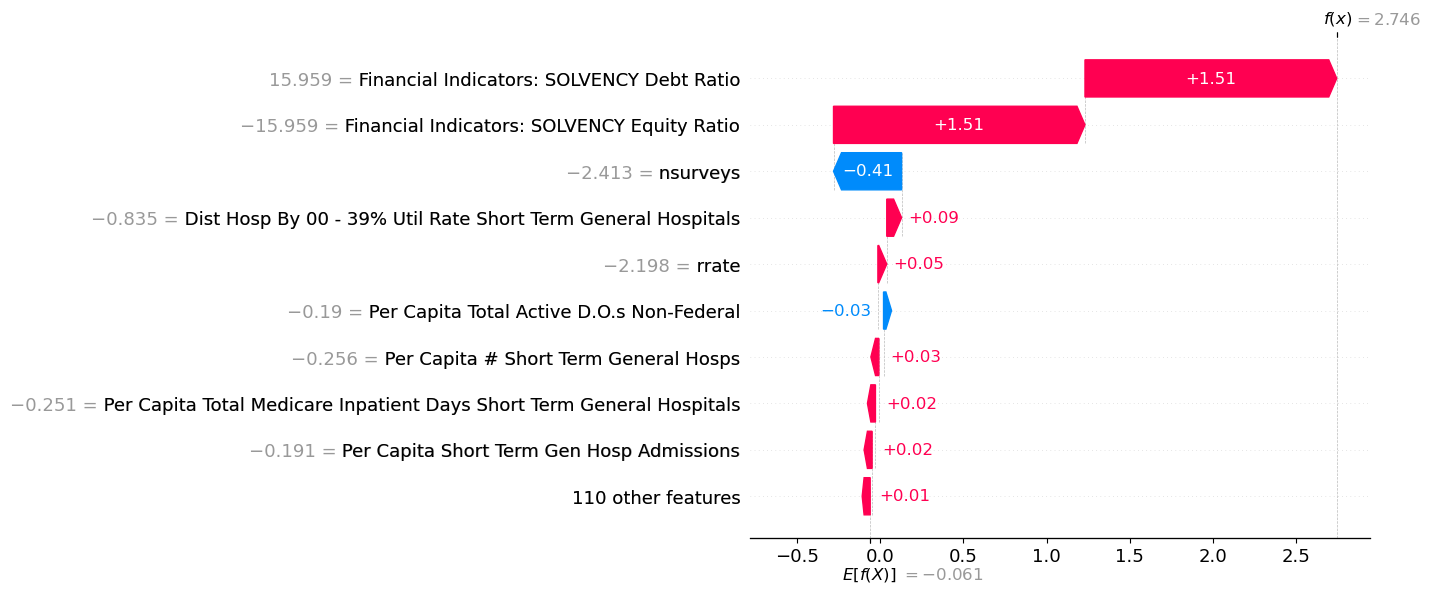

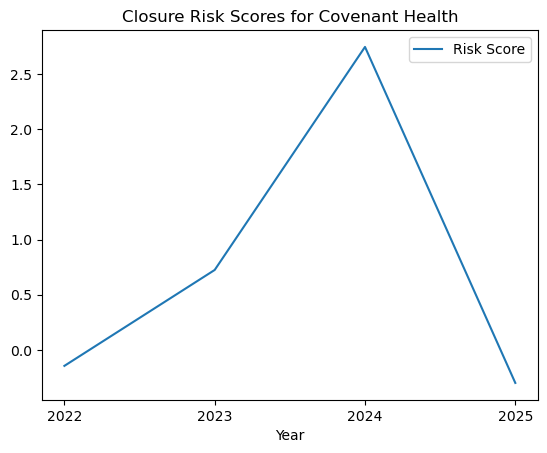

In [33]:
test_full[test_full['Facility Name']=='COVENANT HEALTH HOBBS HOSPITAL'].plot(kind='line',x='Year',y='Pred_Closure')
plt.title('Closure Risk Scores for Covenant Health')
plt.xticks([2022, 2023, 2024, 2025])
plt.legend(['Risk Score'])
plt.savefig("../app/images/covenant_scores.png", bbox_inches="tight", dpi=300)
plt.show()

In [34]:
# COVENANT HEALTH HOBBS HOSPITAL in 2024
shap.plots.waterfall(exp[759],show=False)
plt.savefig("../app/images/covenant_health_hobbs_2024.png", bbox_inches="tight", dpi=300)

In [36]:
# COVENANT HEALTH HOBBS HOSPITAL in 2025
shap.plots.waterfall(exp[760],show=False)
plt.savefig("../app/images/covenant_health_hobbs_2025.png", bbox_inches="tight", dpi=300)